In [1]:
import jax.numpy as jnp
from jax import random
import jax
from flax.training import train_state
import optax
from flax import linen as nn
from tqdm.notebook import tqdm
# Optionally, you can save the losses to a file or plot them
import matplotlib.pyplot as plt
import numpy as np
import sys

jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')


# Polynomial examples 

This is the notebook to generate figures for the polynomial regression examples; based on the transition from laziness paper. Much of the code is copied pasted from their example with our analysis. 

In [2]:
# Model
class NNFunc(nn.Module):
    alpha: float
    eps: float = 0.25
    D: int = 100
    N: int = 500

    def setup(self):
        # This initialization didn't work hmmm 
        # self.W = self.param('W', nn.initializers.normal(), (self.N,self.D))
        self.W = self.param('W', random.normal, (self.N,self.D))

    def __call__(self, X):
        h = jnp.dot(self.W, X) / jnp.sqrt(self.D)
        f = self.alpha * jnp.mean(
            h + 0.5 * self.eps * h**2, axis=0
        )
        return f

In [3]:
# Create data
D = 100
P = 450
N = 500

X = random.normal(random.PRNGKey(0), (D,P))
Xt = random.normal(random.PRNGKey(1), (D,1000))
beta = random.normal(random.PRNGKey(2), (D,))

def target_fn(beta, X):
    return (X.T @ beta / jnp.sqrt(D))**2

y = target_fn(beta, X)
yt = target_fn(beta,Xt)

# Add noise to the y variable
# noise_std = 0.01  # Standard deviation of the noise
# noise = random.normal(random.PRNGKey(3), y.shape) * noise_std
# y = y + noise


# Alphas scaling

We write the train functions; for simplicity, we split it into "precond" vs "noprecond".

In [11]:
def train_alphas_noprecond(alphas = [2**(-5),0.25,0.5,1.0,2.0,4.0,8.0,16,32],
          iterations = 10001,
          output_models: bool=False, 
          num_runs: int = 5
        ):
    all_tr_losses = {}
    all_te_losses = {}
    all_params = {}
    all_models = {}

    # Optimizer
    eta = 0.5 * N
    # eta = 5e-4 * N # This works.... a little bit for Gauss-Newton 
    tx = optax.sgd(learning_rate=eta)


    for alpha in alphas:
        all_tr_losses[alpha] = []
        all_te_losses[alpha] = []
        all_params[alpha] = []
        all_models[alpha] = []


        for k in range(1, num_runs + 1):
            # Make model 
            # Initialize the model
            model = NNFunc(alpha=alpha, eps=0.25, D=D, N=N)
            all_models[alpha].append(model) # Not efficient but memory is cheap for small problems
            params = model.init(jax.random.PRNGKey(k), X)
            state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)
    
            # Save intiializer 
            init_params = state.params
    
            @jax.jit
            def loss_fn(params, x, y):
                loss = jnp.mean(
                    (state.apply_fn(params, x) - state.apply_fn(init_params, x) - y) ** 2 / alpha**2
                )
                return loss
    
            @jax.jit
            def train_step(state):
                loss, grads = jax.value_and_grad(loss_fn)(state.params, X, y)
                state = state.apply_gradients(grads=grads)
                return state, loss
    
            tr_losses = []
            te_losses = []
            params = []
            for t in tqdm(range(iterations)):
                if t % 8 == 0 and output_models:
                    params.append(state.params)
                    
                state, loss = train_step(state)
                
                if t % 2 == 0:
                    train_loss = alpha**2*loss_fn(state.params, X, y)
                    test_loss = alpha**2*loss_fn(state.params, Xt, yt)
                    tr_losses += [train_loss]
                    te_losses += [test_loss]
                    sys.stdout.write(f'\r t: {t} | train loss: {train_loss} | test loss: {test_loss}')
    
                if t % 10000 == 0:
                    print(" ")
    
            all_tr_losses[alpha] += [tr_losses]
            all_te_losses[alpha] += [te_losses]
            all_params[alpha] += [params]

    if output_models:
        return all_tr_losses, all_te_losses, all_params, all_models
    return all_tr_losses, all_te_losses


def train_alphas_precond(alphas = [2**(-5),0.25,0.5,1.0,2.0,4.0,8.0,16,32],
          iterations = 10001,
            output_models: bool=False,
            num_runs: int = 5,
        ):
    all_tr_losses = {}
    all_te_losses = {}
    all_params = {}
    all_models = {}

    # Optimizer
    eta = 0.5 * N
    # eta = 5e-4 * N # This works.... a little bit for Gauss-Newton 
    tx = optax.sgd(learning_rate=eta)


    for alpha in alphas: 
        all_tr_losses[alpha] = []
        all_te_losses[alpha] = []
        all_params[alpha] = []
        all_models[alpha] = []
        
        for k in range(1, num_runs + 1): 
            # Make model 
            # Initialize the model
            model = NNFunc(alpha=alpha, eps=0.25, D=D, N=N)
            params = model.init(jax.random.PRNGKey(k), X)
            all_models[alpha].append(model)
            state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)
    
            # Save intiializer 
            init_params = state.params
    
            @jax.jit
            def loss_fn(params, x, y):
                loss = jnp.mean(
                    (state.apply_fn(params, x) - state.apply_fn(init_params, x) - y) ** 2 / alpha**2
                )
                return loss
    
            @jax.jit
            def train_step(state):
                loss, grads = jax.value_and_grad(loss_fn)(state.params, X, y)
    
                # if precond == 'smw':
                # TODO: change alpha to match Variance as suggested by Alexey
                print('Running SMW')
                lamb = 1e-1 / alpha # THIS IS THE SCALING HERE
    
                _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, X), (state.params,), (grads,))
                jacobian_fn = jax.jacrev(
                    lambda params, x: state.apply_fn(params, x)
                )(state.params, X)
                flat_jacobian = []
                for layer in jacobian_fn['params'].values():
                    flat_jacobian.append(layer.reshape(450, -1))
                jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
                mat = jacobian_fn @ jacobian_fn.T
    
                out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
                _, vjp_fn = jax.vjp( lambda params, x: state.apply_fn(params, x), state.params, X)
                adjustment = vjp_fn(out)[0] 
                grads = jax.tree.map(lambda a, b: 1 / lamb * a - b, grads, adjustment)
    
                state = state.apply_gradients(grads=grads)
                return state, loss
    
            tr_losses = []
            te_losses = []
            params = []
            for t in tqdm(range(iterations)):
                if t % 8 == 0 and output_models:
                    params.append(state.params)
                    
                state, loss = train_step(state)
                
                if t % 2 == 0:
                    train_loss = alpha**2*loss_fn(state.params, X, y)
                    test_loss = alpha**2*loss_fn(state.params, Xt, yt)
                    tr_losses += [train_loss]
                    te_losses += [test_loss]
                    sys.stdout.write(f'\r t: {t} | train loss: {train_loss} | test loss: {test_loss}')
    
                if t % 10000 == 0:
                    print(" ")
    
            all_tr_losses[alpha] += [tr_losses]
            all_te_losses[alpha] += [te_losses]
            all_params[alpha] += [params]
        
    if output_models:
        return all_tr_losses, all_te_losses, all_params, all_models
    return all_tr_losses, all_te_losses


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Alphas Runs

In [12]:

alphas = [2**(-5),0.25,0.5,1.0,2.0,4.0,8.0,16,32]
all_tr_loss_original, all_te_losses_original = train_alphas_noprecond(alphas=alphas, iterations=60000,
                                                                                    output_models=False) # This is to get original paper


  0%|          | 0/60000 [00:00<?, ?it/s]

 t: 0 | train loss: 1.8987067530321762 | test loss: 3.201237635369927 
 t: 10000 | train loss: 1.4435526647499167e-05 | test loss: 0.012071419181299977 
 t: 20000 | train loss: 3.5750398878739856e-06 | test loss: 0.006502631372722207 
 t: 30000 | train loss: 1.4070389399397728e-06 | test loss: 0.004698583778515335 
 t: 40000 | train loss: 6.677730903548345e-07 | test loss: 0.0038228347949204465 
 t: 50000 | train loss: 3.506071452014814e-07 | test loss: 0.0033153594085175656 
 t: 59998 | train loss: 1.9597647835572916e-07 | test loss: 0.0029905471400125984

  0%|          | 0/60000 [00:00<?, ?it/s]

 t: 0 | train loss: 1.8987419171414417 | test loss: 3.2012866139896703 
 t: 10000 | train loss: 1.4422078677579803e-05 | test loss: 0.012155134858753757 
 t: 20000 | train loss: 3.5973225724460386e-06 | test loss: 0.00655980119401699 6
 t: 30000 | train loss: 1.4234680168863074e-06 | test loss: 0.004741162336529437 
 t: 40000 | train loss: 6.786267276688088e-07 | test loss: 0.003856532219916106 5
 t: 50000 | train loss: 3.577589749796801e-07 | test loss: 0.0033431180886031183 
 t: 59998 | train loss: 2.0074324163080938e-07 | test loss: 0.0030140631054553756

  0%|          | 0/60000 [00:00<?, ?it/s]

...

 t: 0 | train loss: 1.899427878788797 | test loss: 3.2016852050498277 
 t: 10000 | train loss: 0.03319795730168185 | test loss: 2.322820982385294 
 t: 20000 | train loss: 0.0033290354920662945 | test loss: 2.296230856413902 
 t: 30000 | train loss: 0.0004980428760518875 | test loss: 2.2895349885080214 
 t: 40000 | train loss: 8.973146889370392e-05 | test loss: 2.28742208902648 65
 t: 50000 | train loss: 1.801754507847689e-05 | test loss: 2.2866780775051656 
 t: 59998 | train loss: 3.878610289042613e-06 | test loss: 2.28639515829409226

  0%|          | 0/60000 [00:00<?, ?it/s]

 t: 0 | train loss: 1.8994199277696875 | test loss: 3.2017206961055074 
 t: 10000 | train loss: 0.03351589144097058 | test loss: 2.3092051637328943 
 t: 20000 | train loss: 0.0032888916749981728 | test loss: 2.2814657936408356 
 t: 30000 | train loss: 0.00048643551160483934 | test loss: 2.2746413610450356 
 t: 40000 | train loss: 8.737739887559756e-05 | test loss: 2.272537111918416 5
 t: 50000 | train loss: 1.764059254164914e-05 | test loss: 2.271820980732113 6
 t: 59998 | train loss: 3.848941219971238e-06 | test loss: 2.27156281418405865

  0%|          | 0/60000 [00:00<?, ?it/s]

 t: 0 | train loss: 1.8993556719152664 | test loss: 3.2016770409387796 
 t: 10000 | train loss: 0.03241333323097195 | test loss: 2.3120680930444553 
 t: 20000 | train loss: 0.003262626140542363 | test loss: 2.2820343620662564 
 t: 30000 | train loss: 0.0004955005337750419 | test loss: 2.2748923421160328 
 t: 40000 | train loss: 9.030714344831646e-05 | test loss: 2.272734620041001 3
 t: 50000 | train loss: 1.819924678136886e-05 | test loss: 2.2719962999585044 
 t: 59998 | train loss: 3.908185543177847e-06 | test loss: 2.27172295672332465

In [15]:
import pickle

# Save to a pickle file
with open('tr_loss_original.pkl', 'wb') as file:
    pickle.dump((all_tr_loss_original, all_te_losses_original), file)

0.03125
0.25
0.5
1.0
2.0
4.0
8.0
16


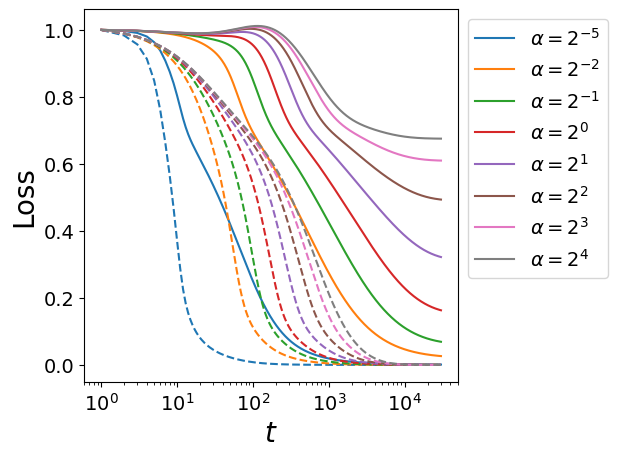

In [14]:
plt.rcParams.update({'font.size': 14})
plt.figure()
for i,alpha in enumerate(alphas[:-1]):
    print(alpha)
    plt.plot(jnp.linspace(1,len(all_tr_loss_original[alpha][0]),len(all_tr_loss_original[alpha][0])), jnp.array(all_tr_loss_original[alpha][0]) / all_tr_loss_original[alpha][0][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_loss_original[alpha][0]),len(all_tr_loss_original[alpha][0])), jnp.array(all_te_losses_original[alpha][0]) / all_te_losses_original[alpha][0][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))

plt.xscale('log')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



In [16]:
alphas = [2**(-5),0.25,0.5,1.0,2.0,4.0,8.0,16,32]

all_tr_losses, all_te_losses = train_alphas_precond(alphas=alphas, iterations=10001,
                                                   output_models=False) # Uncomment code to get SMW

with open('tr_loss.pkl', 'wb') as file:
    pickle.dump((all_tr_losses, all_te_losses), file)

  0%|          | 0/10001 [00:00<?, ?it/s]

Running SMW
 t: 0 | train loss: 1.9063313415139045 | test loss: 3.203241049489793 
 t: 10000 | train loss: 0.00011529047264501995 | test loss: 0.0373552021343934 


  0%|          | 0/10001 [00:00<?, ?it/s]

Running SMW
 t: 0 | train loss: 1.9063422594845503 | test loss: 3.2032557313002217 
 t: 10000 | train loss: 0.00011460345818703982 | test loss: 0.03742443349026637 


  0%|          | 0/10001 [00:00<?, ?it/s]

...

Running SMW
 t: 0 | train loss: 1.905515345198034 | test loss: 3.2023322554486584 
 t: 10000 | train loss: 8.550491552065639e-10 | test loss: 2.288726402054145 


  0%|          | 0/10001 [00:00<?, ?it/s]

Running SMW
 t: 0 | train loss: 1.9055152792781023 | test loss: 3.202352888386205 
 t: 10000 | train loss: 8.554418908636381e-10 | test loss: 2.274030769528227 


  0%|          | 0/10001 [00:00<?, ?it/s]

Running SMW
 t: 0 | train loss: 1.9055141181359203 | test loss: 3.2023454584019193 
 t: 10000 | train loss: 8.53581088560888e-10 | test loss: 2.273100503190979 8


In [ ]:
plt.rcParams.update({'font.size': 10})
plt.figure()
for i,alpha in enumerate(alphas[:-1]):
    print(alpha)
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_tr_losses[i]) / all_tr_losses[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_te_losses[i]) / all_te_losses[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))

plt.xscale('log')
plt.xlabel(r'$t$')
plt.ylabel('Normalized Loss')
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

0.03125
0.25
0.5
1.0
2.0
4.0
8.0
16
0.03125
0.25
0.5
1.0
2.0
4.0
8.0
16


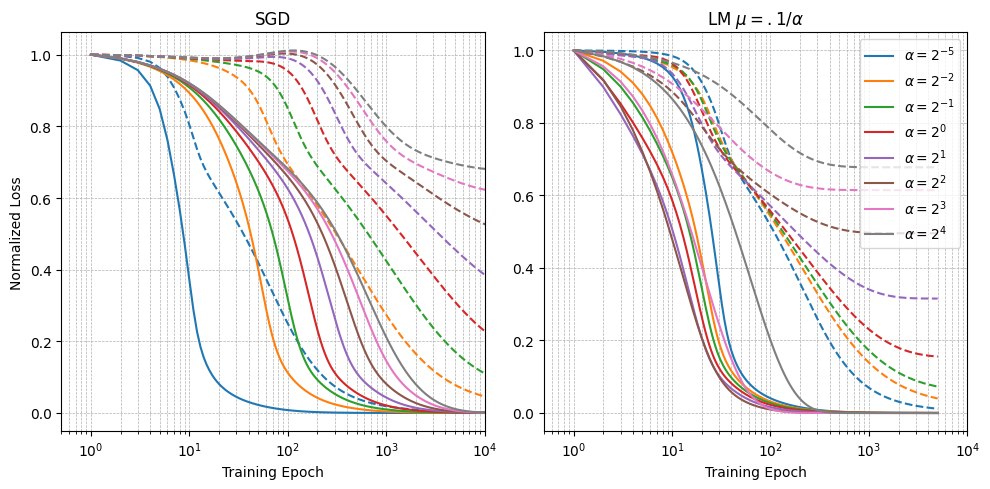

In [8]:
fig, subfigs = plt.subplots(1, 2, figsize=(10, 5))  # 1 row


for i,alpha in enumerate(alphas[:-1]):
    print(alpha)
    subfigs[1].semilogx(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_tr_losses[i]) / all_tr_losses[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))
    subfigs[1].semilogx(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_te_losses[i]) / all_te_losses[i][0], '--',  color = f'C{i}')


subfigs[1].set_xlabel(r'Training Epoch')
subfigs[1].legend(loc='upper right')
subfigs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
subfigs[1].set_xlim(.5, 1e4)
subfigs[1].set_title(r'LM $\mu=.1/\alpha$')

for i,alpha in enumerate(alphas[:-1]):
    print(alpha)
    subfigs[0].semilogx(jnp.linspace(1,len(all_tr_loss_original[i]),len(all_tr_loss_original[i])), jnp.array(all_tr_loss_original[i]) / all_tr_loss_original[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))
    subfigs[0].semilogx(jnp.linspace(1,len(all_tr_loss_original[i]),len(all_tr_loss_original[i])), jnp.array(all_te_losses_original[i]) / all_te_losses_original[i][0],'--',   color = f'C{i}')


subfigs[0].set_xlabel(r'Training Epoch')
subfigs[0].set_ylabel('Normalized Loss')
subfigs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
subfigs[0].set_xlim(.5, 1e4)
subfigs[0].set_title('SGD')

plt.tight_layout()
# plt.savefig('grokking.png')
plt.show()


## FFT plots 

In [9]:
alphas = [2**(-5),0.25,0.5,1.0,2.0,4.0,8.0,16]
all_tr_loss_original, all_te_losses_original, params_original, models_original = train_alphas_noprecond(alphas=alphas, iterations=int(2e4) + 1,
                                                                                    output_models=True) # This is to get original paper

  0%|          | 0/20001 [00:00<?, ?it/s]

 t: 0 | train loss: 1.8987067530321762 | test loss: 3.201237635369927 
 t: 10000 | train loss: 1.4435526647499167e-05 | test loss: 0.012071419181299977 
 t: 20000 | train loss: 3.5750398878739856e-06 | test loss: 0.006502631372722207 


  0%|          | 0/20001 [00:00<?, ?it/s]

 t: 0 | train loss: 1.8993061801335631 | test loss: 3.2016378234303002 
 t: 10000 | train loss: 0.0004573737758671448 | test loss: 0.2510067799966963 
 t: 20000 | train loss: 9.319661656679169e-05 | test loss: 0.14820896622026855 


  0%|          | 0/20001 [00:00<?, ?it/s]

...

 t: 0 | train loss: 1.8993864815684547 | test loss: 3.201691432693134 
 t: 10000 | train loss: 0.008263206178913797 | test loss: 1.8281822762370277 
 t: 20000 | train loss: 0.0013088004861470568 | test loss: 1.687985858068536 


  0%|          | 0/20001 [00:00<?, ?it/s]

 t: 0 | train loss: 1.8993891583684632 | test loss: 3.2016932197200147 
 t: 10000 | train loss: 0.01316643711656566 | test loss: 2.0740718388580928 
 t: 20000 | train loss: 0.0015332606273576288 | test loss: 1.9953398953353876 


  0%|          | 0/20001 [00:00<?, ?it/s]

 t: 0 | train loss: 1.8993904967705364 | test loss: 3.2016941132347 
 t: 10000 | train loss: 0.021444255453810235 | test loss: 2.2271056537157867 
 t: 20000 | train loss: 0.002174718399218091 | test loss: 2.1813796358856927 


In [10]:
all_tr_losses, all_te_losses, params, model = train_alphas_precond(alphas=alphas, iterations=20001,
                                                   output_models=True) # Uncomment code to get SMW

  0%|          | 0/20001 [00:00<?, ?it/s]

Running SMW
 t: 0 | train loss: 1.9063313415139045 | test loss: 3.203241049489793 
 t: 10000 | train loss: 0.00011529047264501995 | test loss: 0.0373552021343934 
 t: 16396 | train loss: 4.832732875512052e-05 | test loss: 0.0226786477293530462

KeyboardInterrupt: 

In [ ]:

def f(model, x, param, init_params):
    return (model.apply(param, x) - model.apply(init_params, x))


In [ ]:
fig, subfigs = plt.subplots(1, 2, figsize=(10, 5))  # 1 row

d = jnp.ones((100, 1))
# d = X[:, 0].reshape((100, 1))
t = jnp.linspace(0, 1, num=100)
x_samples = (d * t)

for i,alpha in enumerate(alphas[:]):
    all_fft = []
    print(i, alpha)
    for t in range(len(params[i])):
        errors = (f(models_original[i], x_samples, params_original[i][t], params_original[i][0]) - target_fn(beta, x_samples)) 
        fft_err = jnp.abs(jnp.fft.fft(errors)) / len(x_samples)
        fft_err = fft_err[:len(x_samples) // 2]
        all_fft.append(fft_err.flatten())
    all_fft = jnp.array(all_fft).T
    subfigs[0].semilogx(jnp.arange(len(all_fft[0, :])) * 4 + 1, all_fft[0, :] / all_fft[0, 0], linestyle='dashed',  color = f'C{i}')
    
for i,alpha in enumerate(alphas[:]):
    all_fft = []
    print(i, alpha)
    for t in range(len(params[i])):
        errors = (f(model[i], x_samples, params[i][t], params[i][0]) - target_fn(beta, x_samples)) 
        fft_err = jnp.abs(jnp.fft.fft(errors)) / len(x_samples)
        fft_err = fft_err[:len(x_samples) // 2]
        all_fft.append(fft_err.flatten())
    all_fft = jnp.array(all_fft).T
    subfigs[1].semilogx(jnp.arange(len(all_fft[0, :])) * 4 + 1, all_fft[0, :]/all_fft[0, 0], linestyle='dashed',  color = f'C{i}',
                        )
    # plt.plot(jnp.arange(len(all_fft[1, :])) * 100, all_fft[1, :])

# d = jnp.ones((100, 1))
d = X[:, 0].reshape((100, 1))
t = jnp.linspace(0, 1, num=100)
x_samples = (d * t)

for i,alpha in enumerate(alphas[:]):
    all_fft = []
    print(i, alpha)
    for t in range(len(params[i])):
        errors = (f(model[i], x_samples, params[i][t], params[i][0]) - target_fn(beta, x_samples)) 
        fft_err = jnp.abs(jnp.fft.fft(errors)) / len(x_samples)
        fft_err = fft_err[:len(x_samples) // 2]
        all_fft.append(fft_err.flatten())
    all_fft = jnp.array(all_fft).T
    subfigs[1].semilogx(jnp.arange(len(all_fft[0, :])) * 4 + 1, all_fft[0, :]/all_fft[0, 0],  color = f'C{i}',
                       label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))

for i,alpha in enumerate(alphas[:]):
    # print(i, alpha)
    # i = 3
    # alpha = 1.0
    all_fft = []
    print(i, alpha)
    for t in range(len(params_original[i])):
        errors = (f(models_original[i], x_samples, params_original[i][t], params_original[i][0]) - target_fn(beta, x_samples))
        fft_err = jnp.abs(jnp.fft.fft(errors))  / len(x_samples)
        fft_err = fft_err[:len(x_samples) // 2]
        all_fft.append(fft_err.flatten())
    all_fft = jnp.array(all_fft).T
    for k in range(1):
        subfigs[0].semilogx(jnp.arange(len(all_fft[0, :])) * 4 + 1, all_fft[0, :] / all_fft[0, 0],  color = f'C{i}')

subfigs[1].set_xlabel(r'Training Epoch')
subfigs[1].legend(loc='upper right')
subfigs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
subfigs[1].set_xlim(.5, 1e4)
subfigs[1].set_title(r'LM $\mu=.1/\alpha$')

subfigs[0].set_xlabel(r'Training Epoch')
subfigs[0].set_ylabel('Normalized Error of Largest Freq')
subfigs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
subfigs[0].set_xlim(.5, 1e4)
subfigs[0].set_title('SGD')

subfigs[0].set_xlim(.5, 1e4)
subfigs[1].set_xlim(.5, 1e4)
plt.tight_layout()
plt.savefig('grokking-error-freq.png')
plt.show()



In [ ]:
fig, subfigs = plt.subplots(1, 2, figsize=(10, 5))  # 1 row

d = jnp.ones((100, 1))
# d = X[:, 0].reshape((100, 1))
t = jnp.linspace(0, 1, num=100)
x_samples = (d * t)

# for i,alpha in enumerate(alphas[0:4]):
#     all_fft = []
#     print(i, alpha)
#     # for t in range(len(params[i])):
#     for t in range(100):
#         errors = (f(models_original[i], x_samples, params_original[i][t], params_original[i][0]) - target_fn(beta, x_samples)) 
#         fft_err = jnp.abs(jnp.fft.fft(errors)) / len(x_samples)
#         fft_err = fft_err[:len(x_samples) // 2]
#         all_fft.append(fft_err.flatten())
#     all_fft = jnp.array(all_fft).T
#     for k in range(20):
#         subfigs[0].semilogx(
#             jnp.arange(len(all_fft[0, :])) * 2 + 1, all_fft[k, :] / all_fft[k, 0] , linestyle='dashed',  color = f'C{i}'
#         )
#         # print(k)
    
# for i,alpha in enumerate(alphas[:-4]):
#     all_fft = []
#     print(i, alpha)
#     for t in range(len(params[i])):
#         errors = (f(model[i], x_samples, params[i][t], params[i][0]) - target_fn(beta, x_samples)) 
#         fft_err = jnp.abs(jnp.fft.fft(errors)) / len(x_samples)
#         fft_err = fft_err[:len(x_samples) // 2]
#         all_fft.append(fft_err.flatten())
#     all_fft = jnp.array(all_fft).T
#     subfigs[1].semilogx(jnp.arange(len(all_fft[0, :])) * 2 + 1, all_fft[0, :]/all_fft[0, 0], linestyle='dashed',  color = f'C{i}',
                        # )

# d = jnp.ones((100, 1))
d = X[:, 0].reshape((100, 1))
t = jnp.linspace(0, 1, num=100)
x_samples = (d * t)

# for i,alpha in enumerate(alphas[:-1]):
#     all_fft = []
#     print(i, alpha)
#     for t in range(len(params[i])):
#         errors = (f(model[i], x_samples, params[i][t], params[i][0]) - target_fn(beta, x_samples)) 
#         fft_err = jnp.abs(jnp.fft.fft(errors)) / len(x_samples)
#         fft_err = fft_err[:len(x_samples) // 2]
#         all_fft.append(fft_err.flatten())
#     all_fft = jnp.array(all_fft).T
#     subfigs[1].semilogx(jnp.arange(len(all_fft[0, :])) * 2 + 1, all_fft[0, :]/all_fft[0, 0],  color = f'C{i}',
#                        label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))

for i,alpha in enumerate(alphas[0:4]):
    # print(i, alpha)
    # i = 3
    # alpha = 1.0
    all_fft = []
    print(i, alpha)
    # for t in range(len(params_original[i])):
    for t in range(100):
        errors = (f(models_original[i], x_samples, params_original[i][t], params_original[i][0]) - target_fn(beta, x_samples))
        fft_err = jnp.abs(jnp.fft.fft(errors))  / len(x_samples)
        fft_err = fft_err[:len(x_samples) // 2]
        all_fft.append(fft_err.flatten())
    all_fft = jnp.array(all_fft).T
    for k in range(5):
        subfigs[0].semilogx(jnp.arange(len(all_fft[0, :])) * 2 + 1, all_fft[k, :] / all_fft[k, 0],  color = f'C{i}')

subfigs[1].set_xlabel(r'Training Epoch')
subfigs[1].legend(loc='upper right')
subfigs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
subfigs[1].set_xlim(.5, 1e4)
subfigs[1].set_title(r'LM $\mu=.1/\alpha$')

subfigs[0].set_xlabel(r'Training Epoch')
subfigs[0].set_ylabel('Normalized Error of Largest Freq')
subfigs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
subfigs[0].set_xlim(.5, 1e4)
subfigs[0].set_title('SGD')

subfigs[0].set_xlim(.5, 1e4)
subfigs[1].set_xlim(.5, 1e4)
plt.tight_layout()
plt.savefig('grokking-error-freq.png')
plt.show()



# Scaling with epsilon

So the hypothesis here is that while 
I THINK WE NEED TO USE HIGHER PRECISION HERE!!!

we just change the body and rewrite it ... 

In [ ]:
def train_eps_noprecond(epsilons = [0.25,0.5,1.0,2.0,4.0],
          iterations = 20001,
        params  = None
        ):
    all_tr_losses = []
    all_te_losses = []
    
    # Optimizer
    eta = 0.5 * N
    tx = optax.sgd(learning_rate=eta)

    alpha = 1.0
    for epsilon in epsilons: 
        # Make model 
        # Initialize the model
        model = NNFunc(alpha=alpha, eps=epsilon, D=D, N=N)
        if not params:
            params = model.init(jax.random.PRNGKey(1), X)
        state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

        # Save intiializer 
        init_params = state.params

        @jax.jit
        def loss_fn(params, x, y):
            loss = jnp.mean(
                (state.apply_fn(params, x) - state.apply_fn(init_params, x) - y) ** 2 / alpha**2
            )
            return loss

        @jax.jit
        def train_step(state):
            loss, grads = jax.value_and_grad(loss_fn)(state.params, X, y)
            state = state.apply_gradients(grads=grads)
            return state, loss
            
        tr_losses = []
        te_losses = []
        for t in tqdm(range(iterations)):
            
            if t % 2 == 0:
                train_loss = alpha**2*loss_fn(state.params, X, y)
                test_loss = alpha**2*loss_fn(state.params, Xt, yt)
                tr_losses += [train_loss]
                te_losses += [test_loss]
                sys.stdout.write(f'\r t: {t} | train loss: {train_loss} | test loss: {test_loss}')

            if t % 10000 == 0:
                print(" ")
            state, loss = train_step(state)

        all_tr_losses += [tr_losses]
        all_te_losses += [te_losses]
    
    return all_tr_losses, all_te_losses


def train_eps_precond(epsilons = [0.25,0.5,1.0,2.0,4.0],
          iterations = 20001,
        lamb = 1e-2
        ):
    all_tr_losses = []
    all_te_losses = []
    
    # Optimizer
    eta = 0.5 * N
    tx = optax.sgd(learning_rate=eta)

    alpha = 1.0
    for epsilon in epsilons: 
        # Make model 
        # Initialize the model
        model = NNFunc(alpha=alpha, eps=epsilon, D=D, N=N)
        params = model.init(jax.random.PRNGKey(1), X)
        state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

        # Save intiializer 
        init_params = state.params

        @jax.jit
        def loss_fn(params, x, y):
            loss = jnp.mean(
                (state.apply_fn(params, x) - state.apply_fn(init_params, x) - y) ** 2 / alpha**2
            )
            return loss

        @jax.jit
        def train_step(state):
            loss, grads = jax.value_and_grad(loss_fn)(state.params, X, y)
            
            print('Running SMW')

            _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, X), (state.params,), (grads,))
            jacobian_fn = jax.jacrev(
                lambda params, x: state.apply_fn(params, x)
            )(state.params, X)
            flat_jacobian = []
            for layer in jacobian_fn['params'].values():
                flat_jacobian.append(layer.reshape(450, -1))
            jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
            mat = jacobian_fn @ jacobian_fn.T

            out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
            _, vjp_fn = jax.vjp( lambda params, x: state.apply_fn(params, x), state.params, X)
            adjustment = vjp_fn(out)[0] 
            grads = jax.tree.map(lambda a, b: 1 / lamb * a - b, grads, adjustment)

            state = state.apply_gradients(grads=grads)
            return state, loss
            
        @jax.jit
        def train_step_noprecond(state):
            loss, grads = jax.value_and_grad(loss_fn)(state.params, X, y)
            state = state.apply_gradients(grads=grads)
            return state, loss
  
        tr_losses = []
        te_losses = []
        for t in tqdm(range(iterations)):            
            if t % 2 == 0:
                train_loss = alpha**2*loss_fn(state.params, X, y)
                test_loss = alpha**2*loss_fn(state.params, Xt, yt)
                tr_losses += [train_loss]
                te_losses += [test_loss]
                sys.stdout.write(f'\r t: {t} | train loss: {train_loss} | test loss: {test_loss}')

            if t % 10000 == 0:
                print(" ")
            state, loss = train_step(state)

        # for t in tqdm(range(iterations)):
        #     state, loss = train_step_noprecond(state)
            
        #     if t % 2 == 0:
        #         train_loss = alpha**2*loss_fn(state.params, X, y)
        #         test_loss = alpha**2*loss_fn(state.params, Xt, yt)
        #         tr_losses += [train_loss]
        #         te_losses += [test_loss]
        #         sys.stdout.write(f'\r t: {t} | train loss: {train_loss} | test loss: {test_loss}')

        #     if t % 10000 == 0:
        #         print(" ")

        all_tr_losses += [tr_losses]
        all_te_losses += [te_losses]
    
    return all_tr_losses, all_te_losses


In [ ]:
epsilons = [.25, 1.0, 4.0]
all_tr_losses_eps, all_te_losses_eps = train_eps_noprecond(epsilons = epsilons,
          iterations = 50001,
        )

In [ ]:
plt.rcParams.update({'font.size': 14})
plt.figure()
for i,wscale in enumerate(epsilons):
    plt.plot(jnp.linspace(1,len(all_tr_losses_eps[i]),len(all_tr_losses_eps[i])), jnp.array(all_tr_losses_eps[i]) / all_tr_losses_eps[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses_eps[i]),len(all_tr_losses_eps[i])), jnp.array(all_te_losses_eps[i]) / all_te_losses_eps[i][0],  color = f'C{i}', label = r'$\varepsilon = 2^{%0.0f}$' % jnp.log2(wscale))
plt.xscale('log')
plt.xlabel('t',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
epsilons = [.25, 1.0,  4.0]
all_tr_losses_eps_smw, all_te_losses_eps_smw = train_eps_precond(epsilons = epsilons,
          iterations = 2_001,
        lamb=1e-2
        )

In [ ]:
plt.rcParams.update({'font.size': 14})
plt.figure()
for i,wscale in enumerate(epsilons):
    plt.plot(jnp.linspace(1,len(all_tr_losses_eps_smw[i]),len(all_tr_losses_eps_smw[i])), jnp.array(all_tr_losses_eps_smw[i]) / all_tr_losses_eps_smw[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses_eps_smw[i]),len(all_tr_losses_eps_smw[i])), jnp.array(all_te_losses_eps_smw[i]) / all_te_losses_eps_smw[i][0],  color = f'C{i}', label = r'$\varepsilon = 2^{%0.0f}$' % jnp.log2(wscale))
plt.xscale('log')
plt.xlabel('t',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
epsilons = [0.25,1.0,4.0]
plt.rcParams.update({'font.size': 14})
plt.figure()
for i,wscale in enumerate(epsilons):
    plt.plot(jnp.linspace(1,len(all_tr_losses_eps_smw[i]),len(all_tr_losses_eps_smw[i])), jnp.array(all_tr_losses_eps_smw[i]) / all_tr_losses_eps_smw[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses_eps_smw[i]),len(all_tr_losses_eps_smw[i])), jnp.array(all_te_losses_eps_smw[i]) / all_te_losses_eps_smw[i][0],  color = f'C{i}', label = r'$\varepsilon = 2^{%0.0f}$' % jnp.log2(wscale))

for i,wscale in enumerate(epsilons):
    plt.plot(jnp.linspace(1,len(all_tr_losses_eps[i]),len(all_tr_losses_eps[i])), jnp.array(all_tr_losses_eps[i]) / all_tr_losses_eps[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses_eps[i]),len(all_tr_losses_eps[i])), jnp.array(all_te_losses_eps[i]) / all_te_losses_eps[i][0],  color = f'C{i}', label = r'$\varepsilon = 2^{%0.0f}$' % jnp.log2(wscale))

plt.xscale('log')
plt.xlabel('t',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.tight_layout()
plt.show()
